# A/B Testing
A/B Testing membantu menemukan pendekatan yang lebih baik dalam menjaring pelanggan, memasarkan produk, memperluas jangkauan, atau hal lain yang dapat membantu bisnis mengubah sebagian besar pelanggan sasarannya menjadi pelanggan yang sebenarnya.

# Problem Statements
1. Campaign mana yang paling bagus?
2. Apakah biaya marketing menjadi lebih efisien?
3. Rekomendasi apa yang sebaiknya dilakukan?

# Import Library


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Data Wrangling

## Load Dat

In [2]:
!kaggle datasets download amirmotefaker/ab-testing-dataset

Dataset URL: https://www.kaggle.com/datasets/amirmotefaker/ab-testing-dataset
License(s): other
100% 2.07k/2.07k [00:00<00:00, 4.06MB/s]



In [3]:
!unzip ab-testing-dataset.zip


Archive:  ab-testing-dataset.zip
  inflating: control_group.csv       
  inflating: test_group.csv          


In [4]:
test = pd.read_csv('test_group.csv', sep=';')
control = pd.read_csv('control_group.csv', sep=';')

# Menggabungkan kedau dataset
df = pd.concat([test, control])
df.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Test Campaign,1.08.2019,3008,39550.0,35820.0,3038.0,1946.0,1069.0,894.0,255.0
1,Test Campaign,2.08.2019,2542,100719.0,91236.0,4657.0,2359.0,1548.0,879.0,677.0
2,Test Campaign,3.08.2019,2365,70263.0,45198.0,7885.0,2572.0,2367.0,1268.0,578.0
3,Test Campaign,4.08.2019,2710,78451.0,25937.0,4216.0,2216.0,1437.0,566.0,340.0
4,Test Campaign,5.08.2019,2297,114295.0,95138.0,5863.0,2106.0,858.0,956.0,768.0


## Assesing Data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 0 to 29
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Campaign Name        60 non-null     object 
 1   Date                 60 non-null     object 
 2   Spend [USD]          60 non-null     int64  
 3   # of Impressions     59 non-null     float64
 4   Reach                59 non-null     float64
 5   # of Website Clicks  59 non-null     float64
 6   # of Searches        59 non-null     float64
 7   # of View Content    59 non-null     float64
 8   # of Add to Cart     59 non-null     float64
 9   # of Purchase        59 non-null     float64
dtypes: float64(7), int64(1), object(2)
memory usage: 5.2+ KB


In [6]:
df.describe(include="all")

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
count,60,60,60.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000
unique,2,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Test Campaign,1.08.2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,30,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2425.750000,91775.881356,70868.644068,5682.593220,2321.813559,1900.169492,1087.220339,522.000000
std,NaN,NaN,381.130461,32465.070636,31023.653515,1754.777559,669.040576,687.263844,430.205246,196.973917
min,NaN,NaN,1757.000000,22521.000000,10598.000000,2277.000000,1001.000000,848.000000,278.000000,222.000000
25%,NaN,NaN,2073.750000,68853.500000,43230.000000,4227.500000,1962.500000,1249.000000,848.500000,340.000000
50%,NaN,NaN,2420.500000,95843.000000,76219.000000,5691.000000,2390.000000,1975.000000,1075.000000,501.000000
75%,NaN,NaN,2727.500000,117315.000000,95490.500000,7218.500000,2778.500000,2424.000000,1386.500000,693.000000


In [7]:
df.isna().sum()


,0
Campaign Name,0
Date,0
Spend [USD],0
# of Impressions,1
Reach,1
# of Website Clicks,1
# of Searches,1
# of View Content,1
# of Add to Cart,1
# of Purchase,1


## Data Cleaing

In [8]:
df_clean = df.dropna()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 59 entries, 0 to 29
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Campaign Name        59 non-null     object 
 1   Date                 59 non-null     object 
 2   Spend [USD]          59 non-null     int64  
 3   # of Impressions     59 non-null     float64
 4   Reach                59 non-null     float64
 5   # of Website Clicks  59 non-null     float64
 6   # of Searches        59 non-null     float64
 7   # of View Content    59 non-null     float64
 8   # of Add to Cart     59 non-null     float64
 9   # of Purchase        59 non-null     float64
dtypes: float64(7), int64(1), object(2)
memory usage: 5.1+ KB


In [9]:
df_clean.columns = [
    "Campaign",
    "Date",
    "Spend",
    "Impressions",
    "Reach",
    "Click",
    "Searches",
    "ViewContent",
    "AddToCart",
    "Purchase"
]

In [10]:
df_clean["Date"] = pd.to_datetime(df_clean["Date"], format = "%d.%m.%Y")
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 59 entries, 0 to 29
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Campaign     59 non-null     object        
 1   Date         59 non-null     datetime64[ns]
 2   Spend        59 non-null     int64         
 3   Impressions  59 non-null     float64       
 4   Reach        59 non-null     float64       
 5   Click        59 non-null     float64       
 6   Searches     59 non-null     float64       
 7   ViewContent  59 non-null     float64       
 8   AddToCart    59 non-null     float64       
 9   Purchase     59 non-null     float64       
dtypes: datetime64[ns](1), float64(7), int64(1), object(1)
memory usage: 5.1+ KB


/tmp/ipykernel_4204/3752714632.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Date"] = pd.to_datetime(df_clean["Date"], format = "%d.%m.%Y")


# Feature Engineering

In [11]:
df_clean["CTR"] = df_clean["Click"] / df_clean['Impressions'] # Click Through rate
df_clean["ReachRate"] = df_clean["Reach"] / df_clean["Impressions"]
df_clean["SearchRate"] = df_clean["Searches"] / df_clean["Click"]
df_clean["PurchaseRate"] = df_clean["Purchase"] / df_clean['AddToCart']
df_clean["ViewRate"] = df_clean['ViewContent']/ df_clean['Searches']
df_clean["CartRate"] = df_clean["AddToCart"] / df_clean["Purchase"]
df_clean["PurchaseRatePerClick"] = df_clean["Purchase"] / df_clean["Click"]
df_clean["CPA"] = df_clean["Spend"] / df_clean["Purchase"] # Cost Per Acquistion

/tmp/ipykernel_4204/1533864445.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["CTR"] = df_clean["Click"] / df_clean['Impressions'] # Click Through rate
/tmp/ipykernel_4204/1533864445.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["ReachRate"] = df_clean["Reach"] / df_clean["Impressions"]
/tmp/ipykernel_4204/1533864445.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the c

# EDA

In [12]:
df_clean.groupby("Campaign").mean(numeric_only=1)

,Spend,Impressions,Reach,Click,Searches,ViewContent,AddToCart,Purchase,CTR,ReachRate,SearchRate,PurchaseRate,ViewRate,CartRate,PurchaseRatePerClick,CPA
Campaign,,,,,,,,,,,,,,,,
Control Campaign,2304.068966,109559.758621,88844.931034,5320.793103,2221.310345,1943.793103,1300.000000,522.793103,0.050959,0.804075,0.441216,0.457179,0.873457,2.85851,0.114772,5.052339
Test Campaign,2563.066667,74584.800000,53491.566667,6032.333333,2418.966667,1858.000000,881.533333,521.233333,0.102423,0.717625,0.437376,0.617949,0.756452,1.74026,0.092312,5.899589


In [13]:
df_clean.groupby("Campaign").median(numeric_only=1)

,Spend,Impressions,Reach,Click,Searches,ViewContent,AddToCart,Purchase,CTR,ReachRate,SearchRate,PurchaseRate,ViewRate,CartRate,PurchaseRatePerClick,CPA
Campaign,,,,,,,,,,,,,,,,
Control Campaign,2319.0,113430.0,91579.0,5224.0,2390.0,1984.0,1339.0,501.0,0.047202,0.815647,0.401258,0.426979,0.865043,2.342037,0.102275,4.621005
Test Campaign,2584.0,68853.5,44219.5,6242.5,2395.5,1881.0,974.0,500.0,0.080359,0.772167,0.395202,0.621403,0.785126,1.609263,0.084543,5.062840


In [14]:
df_clean.groupby("Campaign").std(numeric_only=1)

,Spend,Impressions,Reach,Click,Searches,ViewContent,AddToCart,Purchase,CTR,ReachRate,SearchRate,PurchaseRate,ViewRate,CartRate,PurchaseRatePerClick,CPA
Campaign,,,,,,,,,,,,,,,,
Control Campaign,363.534822,21688.922908,21832.349595,1757.369003,866.089368,777.545469,407.457973,185.028642,0.020508,0.069878,0.182065,0.276036,0.056847,1.501756,0.068383,2.117020
Test Campaign,348.687681,32121.377422,28795.775752,1708.567263,388.742312,597.654669,347.584248,211.047745,0.067709,0.181455,0.154182,0.151467,0.171857,0.544081,0.044490,2.800766


## Funnel Metrics
struktur funnel: **Impressions -> Click -> Searches
-> ViewContent -> AddToCart -> Purchase**

In [15]:

funnel = df_clean.groupby("Campaign")[
[
"Impressions",
"Reach",
"Click",
"Searches",
"ViewContent",
"AddToCart",
"Purchase"
]]
funnel.head()

,Impressions,Reach,Click,Searches,ViewContent,AddToCart,Purchase
0,39550.0,35820.0,3038.0,1946.0,1069.0,894.0,255.0
1,100719.0,91236.0,4657.0,2359.0,1548.0,879.0,677.0
2,70263.0,45198.0,7885.0,2572.0,2367.0,1268.0,578.0
3,78451.0,25937.0,4216.0,2216.0,1437.0,566.0,340.0
4,114295.0,95138.0,5863.0,2106.0,858.0,956.0,768.0
0,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
5,109076.0,87998.0,4028.0,1709.0,1249.0,784.0,764.0


In [16]:
rate = df_clean.groupby("Campaign")[
[
"CTR",
"ReachRate",
"SearchRate",
"PurchaseRate",
"ViewRate",
"CartRate",
"PurchaseRatePerClick",
"CPA"
]]

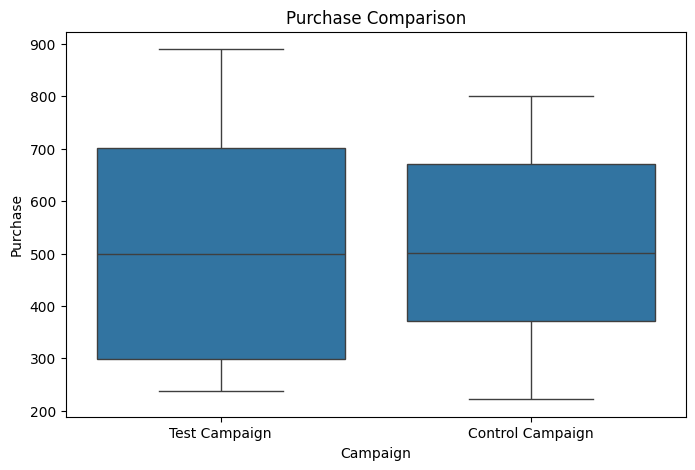

In [17]:
# Boxplot Purchase
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Campaign",
    y="Purchase"
)

plt.title("Purchase Comparison")
plt.show()

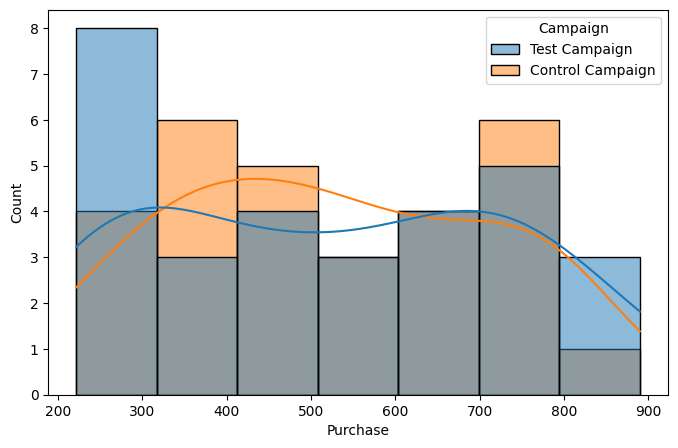

In [18]:
# Distribusi Purchase
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x="Purchase",
    hue="Campaign",
    kde=True
)

plt.show()

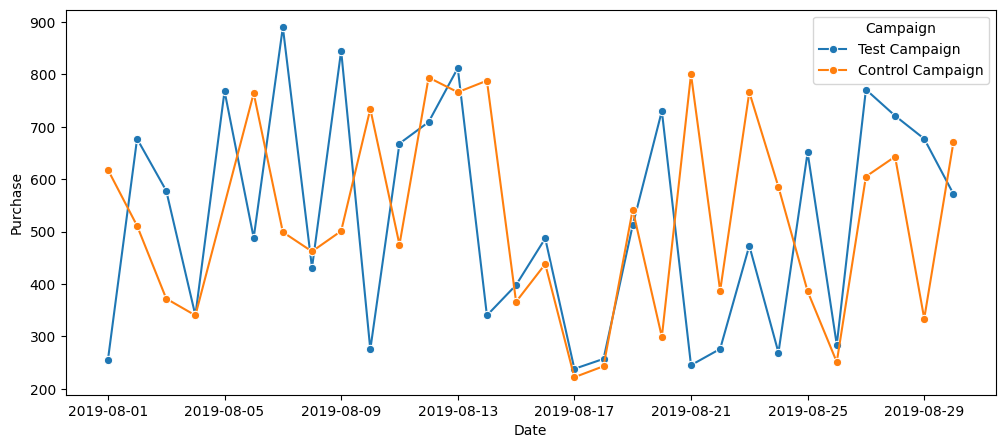

In [19]:
# Tren Harian
plt.figure(figsize=(12,5))

sns.lineplot(
    data=df_clean,
    x="Date",
    y="Purchase",
    hue="Campaign",
    marker="o"
)

plt.show()

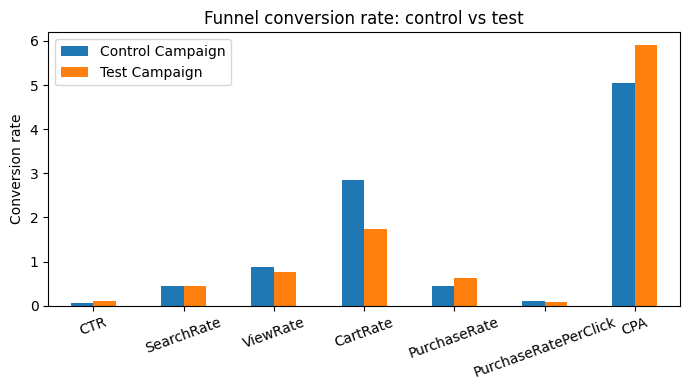

In [20]:
# Funnel Comparation
fig, ax = plt.subplots(figsize=(7, 4))
rate_summary = df_clean.groupby("Campaign")[[
    "CTR",
    "SearchRate",
    "ViewRate",
    "CartRate",
    "PurchaseRate",
    "PurchaseRatePerClick",
    "CPA"
    ]].mean()
rate_summary.T.plot(kind="bar", ax=ax)
ax.set_ylabel("Conversion rate")
ax.set_title("Funnel conversion rate: control vs test")
ax.legend(title="")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Uji Statistik

## Paired Comparasion
Pengujian ini dilakukan karena campaign dilakukan di hari yang sama.<br>
Kita cek dulu asumsi normalitas selisihnya (Shapiro-Wilk), lalu pakai
**paired t-test** kalau normal, atau **Wilcoxon signed-rank test** (versi
non-parametrik) sebagai pembanding.

In [21]:
pivot = df_clean.pivot(index="Date", columns="Campaign", values="Purchase").dropna()
diff = pivot["Test Campaign"] - pivot["Control Campaign"]

shapiro_stat, shapiro_p = stats.shapiro(diff)
print(f"Shapiro-Wilk normality test pada selisih: stat={shapiro_stat:.4f}, p={shapiro_p:.4f}")
print("Selisih terdistribusi normal (p >= 0.05)" if shapiro_p >= 0.05 else "Selisih TIDAK normal (p < 0.05) -- andalkan hasil Wilcoxon")

Shapiro-Wilk normality test pada selisih: stat=0.9626, p=0.3802
Selisih terdistribusi normal (p >= 0.05)


In [22]:
t_stat, p_paired = stats.ttest_rel(pivot["Test Campaign"], pivot["Control Campaign"])
w_stat, p_wilcoxon = stats.wilcoxon(pivot["Test Campaign"], pivot["Control Campaign"])

print(f"Paired t-test      -> t={t_stat:.4f}, p-value={p_paired:.4f}")
print(f"Wilcoxon signed-rank -> stat={w_stat:.4f}, p-value={p_wilcoxon:.4f}")
print()
print(f"Rata-rata purchase harian -- Control Campaign: {pivot['Control Campaign'].mean():.1f}, Test Campaign: {pivot['Test Campaign'].mean():.1f}")
print(f"Selisih rata-rata: {diff.mean():.1f} purchase/hari")
print("Signifikan secara statistik (p < 0.05)"
      if p_paired < 0.05
      else "TIDAK signifikan secara statistik (p >= 0.05) -- belum cukup bukti Test Campaign lebih unggul dari segi jumlah purchase")

Paired t-test      -> t=-0.2063, p-value=0.8380
Wilcoxon signed-rank -> stat=201.0000, p-value=0.9637

Rata-rata purchase harian -- Control Campaign: 522.8, Test Campaign: 512.7
Selisih rata-rata: -10.1 purchase/hari
TIDAK signifikan secara statistik (p >= 0.05) -- belum cukup bukti Test Campaign lebih unggul dari segi jumlah purchase


## CPA

In [23]:
cpa_pivot = df_clean.pivot(index="Date", columns="Campaign", values="CPA").dropna()
cpa_diff = cpa_pivot["Test Campaign"] - cpa_pivot["Control Campaign"]
t_cpa, p_cpa = stats.ttest_rel(cpa_pivot["Test Campaign"], cpa_pivot["Control Campaign"])

print(f"Rata-rata CPA -- Control Campaign: ${cpa_pivot['Control Campaign'].mean():.2f}, Test Campaign: ${cpa_pivot['Test Campaign'].mean():.2f}")
print(f"Paired t-test CPA -> t={t_cpa:.4f}, p-value={p_cpa:.4f}")

Rata-rata CPA -- Control Campaign: $5.05, Test Campaign: $6.00
Paired t-test CPA -> t=1.4725, p-value=0.1520


# Insight
1. Campaign mana yang paling bagus? <br>
    - (`control`) memiliki keunggulan dalam menjangkau banyak orang (rata rata impressions dan reach lebih besar dari (`test`))
    - CTR menunjukkan (`test`) lebih besar 2 kali lipat dari pada (`control`)
    - Secara statisik selisih purchase kedua campaign tidak signifikan  

2. Apakah biaya marketing menjadi lebih efisien?
    - CPA pada (`control`) lebih murah
3. Rekomendasi apa yang sebaiknya dilakukan?
    - Karena hasil purchase tidak berbeda signifikan, keputusan
  sebaiknya condong ke pertimbangan biaya (CPA) dan tujuan strategis, apakah perusahaan lebih mengejar reach/awareness (`control`) atau
  efisiensi targeting (`test`).